# 受賞ポスター — デザイン特徴量抽出 

CSSJ2026 / HPH2024 の受賞ポスター 15 件に対して下記の特徴を抽出してみる

| # | 特徴 | 手法 |
|---|---|---|
| 1 | アスペクト比・ページサイズ | `pdfinfo` / PIL |
| 2 | 支配色パレット (上位5色 + 面積比) | k-means |
| 3 | テキスト密度 | tesseract OCR の bbox 面積比 |
| 4 | 図版/テキスト比 | テキスト mask の補集合を彩度・エッジで分割 |
| 5 | ホワイトスペース比率 | 高輝度・低彩度・低エッジ画素比 |
| 6 | 領域数 (セクション数の代理) | tesseract block / DBSCAN クラスタ |
| 7 | タイトル占有面積・タイトル文字サイズ | 上端帯の最大テキストブロック |
| 8 | エッジ密度 | Canny |
| 9 | 色彩度 (colorfulness) | Hasler & Süsstrunk (2003) |
| 10 | コントラスト | L チャンネル標準偏差 |

LayoutLMv3 (§9.1 #6) はモデルダウンロードが重いため、一旦 tesseract のブロック構造に **DBSCAN** を重ねた近似で代用する。


In [1]:
# ============================================================
# 必要ライブラリの読み込み
# ============================================================
# - pathlib.Path : OS 非依存にファイルパスを扱うための標準ライブラリ
# - subprocess   : pdftoppm / pdfinfo など外部コマンドを呼ぶため
# - numpy        : ピクセル配列を高速に計算
# - pandas       : 表 (DataFrame) としてデータ整形
# - cv2 (OpenCV) : 画像読込・色空間変換・エッジ検出など
# - PIL.Image    : OpenCV より柔軟な画像読込・リサイズ
# - pytesseract  : Tesseract OCR エンジンを Python から呼ぶラッパ
# - sklearn      : KMeans (色クラスタ) / DBSCAN (ブロッククラスタ)
# - japanize_matplotlib : matplotlib の日本語フォント自動設定
import os, re, glob, subprocess, json, tempfile, shutil, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import pytesseract
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import japanize_matplotlib

# DataFrame を広めに表示
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# KMeans の収束時警告などはノートを汚す & ファイルパスを露出させるので抑制
warnings.filterwarnings('ignore')


print('OpenCV    :', cv2.__version__)
print('tesseract :', pytesseract.get_tesseract_version())

OpenCV    : 4.13.0
tesseract : 5.5.2


## 1. 入力パス・PDF→画像変換ユーティリティ

In [2]:
ROOT = Path('.')
AWARD_DIRS = {
    'CSSJ2026': ROOT / 'CSSJ2026_extracted' / 'CSSJ2026' / 'Award',
    'HPH2024':  ROOT / 'HPH2024_extracted' / 'HPH2024' / 'Award',
}
RENDER_DIR = ROOT / '_rendered'
RENDER_DIR.mkdir(exist_ok=True)

def list_award_files():
    rows = []
    for conf, d in AWARD_DIRS.items():
        for p in sorted(d.iterdir()):
            if p.name.startswith('README') or p.name.startswith('.'):
                continue
            rows.append({'conference': conf, 'path': p, 'name': p.name, 'ext': p.suffix.lower()})
    return pd.DataFrame(rows)

files_df = list_award_files()
files_df

,conference,path,name,ext
0,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P1-14_post...,★_P1-14_poster.pdf,.pdf
1,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P1-20_post...,★_P1-20_poster.pdf,.pdf
2,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P1-29_post...,★_P1-29_poster.pdf,.pdf
3,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P1-8_poste...,★_P1-8_poster.pdf,.pdf
4,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P2-18_post...,★_P2-18_poster.pdf,.pdf
5,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P2-33_post...,★_P2-33_poster.pdf,.pdf
6,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P3-10_post...,★_P3-10_poster.pdf,.pdf
7,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P3-16_post...,★_P3-16_poster.pdf,.pdf
8,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P3-35_post...,★_P3-35_poster.pdf,.pdf
9,CSSJ2026,CSSJ2026_extracted/CSSJ2026/Award/★_P3-3_poste...,★_P3-3_poster.pdf,.pdf


### 解像度の正規化 

ポスターにはPDF と JPG が混在しているうえ、PDF の物理サイズも A0 / A1 / A4 になっているなどバラバラである。
このままだと以下のような解像度依存の指標で適切な比較ができない可能性がある

- `edge_density` — 1 pxごとのポスターの密度を計算する。画像のサイズが異なると比較対象が変わってしまう。
- `text_density` — OCR の bbox は画素数に直接依存してしまう。
- `colorfulness` / `contrast_L_std` も実効解像度の影響を受ける

そこで今回は **すべての入力画像を「長辺 = `NORM_LONG_SIDE` px」に揃えてから抽出**する。
具体的には:

1. PDF は一旦 150 dpi で PNG に変換する
2. JPG / PNG / PDF→PNG の すべて を `NORM_LONG_SIDE` (デフォルト 2400 px) に長辺を揃えてリサイズ
3. その正規化済み PNG だけを以降の処理に使う

これで CSSJ (PDF 中心) vs HPH (JPG 混在) を公平に比較できる。
※ ただし JPG の元画像が小さい場合、upscale すると見かけ上のエッジ密度が下がるなどのバイアスは残る。完全な等価ではなく "実効解像度を揃える" 近似であることに注意。

In [3]:

# すべてのポスター画像を同じ長辺 px に揃える。
NORM_LONG_SIDE = 2400  # 長辺の正規化サイズ (px)。OCR にも十分な解像度。

# PDF を中間 PNG にする時の DPI。150 dpi にしておけば A0 でも長辺 ~7000 px となり、
# その後 2400 px に縮小するので、損失は少なそう
PDF_RENDER_DPI = 150


def normalize_size(im: Image.Image, long_side: int = NORM_LONG_SIDE) -> Image.Image:
    """PIL 画像を「長辺 = long_side」になるよう等比リサイズする。

    - 元画像が小さい場合は LANCZOS で拡大 
    - 元画像が大きい場合は LANCZOS で縮小
    """
    w, h = im.size
    if max(w, h) == long_side:
        return im
    r = long_side / max(w, h)
    new_w = max(1, int(round(w * r)))
    new_h = max(1, int(round(h * r)))
    return im.resize((new_w, new_h), Image.LANCZOS)


def render_to_png(src: Path, dpi: int = PDF_RENDER_DPI) -> Path:
    """PDF / JPG / PNG を「正規化済み PNG」として _rendered/ に保存

    同じ stem の PNG が既に存在すればそれを返す。
    """
    out = RENDER_DIR / f"{src.stem}.png"
    if out.exists():
        return out

    if src.suffix.lower() == '.pdf':
        # pdftoppm は poppler 同梱の CLI。-singlefile で 1 ページ目だけ出力。

        cmd = ['pdftoppm', '-png', '-r', str(dpi),
               '-singlefile', str(src), str(out.with_suffix(''))]
        subprocess.run(cmd, check=True, capture_output=True)

        im = Image.open(out).convert('RGB')
    else:
        # JPG / PNG はそのまま PIL で開く
        im = Image.open(src).convert('RGB')

    im = normalize_size(im, NORM_LONG_SIDE)
    im.save(out)
    return out


# まず受賞ポスター 15 件を正規化済み PNG に変換
files_df['png'] = files_df['path'].apply(render_to_png)
files_df[['conference', 'name', 'png']]

,conference,name,png
0,CSSJ2026,★_P1-14_poster.pdf,_rendered/★_P1-14_poster.png
1,CSSJ2026,★_P1-20_poster.pdf,_rendered/★_P1-20_poster.png
2,CSSJ2026,★_P1-29_poster.pdf,_rendered/★_P1-29_poster.png
3,CSSJ2026,★_P1-8_poster.pdf,_rendered/★_P1-8_poster.png
4,CSSJ2026,★_P2-18_poster.pdf,_rendered/★_P2-18_poster.png
5,CSSJ2026,★_P2-33_poster.pdf,_rendered/★_P2-33_poster.png
6,CSSJ2026,★_P3-10_poster.pdf,_rendered/★_P3-10_poster.png
7,CSSJ2026,★_P3-16_poster.pdf,_rendered/★_P3-16_poster.png
8,CSSJ2026,★_P3-35_poster.pdf,_rendered/★_P3-35_poster.png
9,CSSJ2026,★_P3-3_poster.pdf,_rendered/★_P3-3_poster.png


## 2. 特徴 1 — アスペクト比・ページサイズ
PDF は `pdfinfo` から物理サイズ (pt → mm) を取る。JPG はピクセル比のみ。

In [4]:

#   1) PDF から「物理サイズ (mm)」を取り、A0/A1/A4 などに分類する
#   2) 縦長 / 横長 / 正方形 を画素比から判定
#   3) ピクセル単位のアスペクト比も取る
# JPG/PNG は物理サイズが分からないので paper_size = unknown のまま。


def page_size_mm(src: Path):
    """PDF なら pdfinfo を呼び、物理サイズ (mm) を返す。それ以外は None。"""
    if src.suffix.lower() != '.pdf':
        return None, None
    # 例: 'Page size:  2384 x 3370 pts (A0)'  → pts (1 pt = 1/72 inch)
    out = subprocess.run(['pdfinfo', str(src)], capture_output=True, text=True).stdout
    m = re.search(r'Page size:\s+([\d.]+)\s*x\s*([\d.]+)\s*pts', out)
    if not m:
        return None, None
    w_pt, h_pt = float(m.group(1)), float(m.group(2))
    # 1 pt = 25.4/72 mm
    return w_pt * 25.4 / 72, h_pt * 25.4 / 72


def classify_size(w_mm, h_mm):
    """物理サイズの長辺と ISO A 系列を照合してラベル付け。"""
    if w_mm is None:
        return 'unknown'
    long_side = max(w_mm, h_mm)
    # ISO A 系列の長辺長さ (mm)。A4=297, A3=420, ..., A0=1189
    a_series = {'A0': 1189, 'A1': 841, 'A2': 594, 'A3': 420, 'A4': 297}
    # 最も近いラベルを選ぶ。±50 mm 以内なら採用、それ以外は実寸を出す
    name = min(a_series, key=lambda k: abs(a_series[k] - long_side))
    return name if abs(a_series[name] - long_side) < 50 else f'~{int(long_side)}mm'


def orientation(w, h):
    """画素比から縦/横/正方判定。5 % 以内の差なら 'square'。"""
    if abs(w - h) / max(w, h) < 0.05:
        return 'square'
    return 'landscape' if w > h else 'portrait'


# 受賞ポスターを順に処理して、表 (feat1) にまとめる
rows = []
for _, r in files_df.iterrows():
    w_mm, h_mm = page_size_mm(r['path'])
    im = Image.open(r['png'])
    px_w, px_h = im.size  # 正規化後の画素数 (長辺 = NORM_LONG_SIDE)
    rows.append({
        'name': r['name'],
        'conference': r['conference'],
        'w_mm': round(w_mm, 1) if w_mm else None,
        'h_mm': round(h_mm, 1) if h_mm else None,
        'paper_size': classify_size(w_mm, h_mm),
        'orientation': orientation(px_w, px_h),
        'aspect_ratio': round(px_w / px_h, 3),
        'px_w': px_w, 'px_h': px_h,
    })
feat1 = pd.DataFrame(rows)
feat1

,name,conference,w_mm,h_mm,paper_size,orientation,aspect_ratio,px_w,px_h
0,★_P1-14_poster.pdf,CSSJ2026,841.0,1189.0,A0,portrait,0.708,1698,2400
1,★_P1-20_poster.pdf,CSSJ2026,841.0,1189.0,A0,portrait,0.708,1698,2400
2,★_P1-29_poster.pdf,CSSJ2026,190.5,275.1,A4,portrait,0.693,1662,2400
3,★_P1-8_poster.pdf,CSSJ2026,841.0,1189.0,A0,portrait,0.708,1698,2400
4,★_P2-18_poster.pdf,CSSJ2026,841.0,1189.0,A0,portrait,0.708,1698,2400
5,★_P2-33_poster.pdf,CSSJ2026,840.7,1188.9,A0,portrait,0.707,1697,2400
6,★_P3-10_poster.pdf,CSSJ2026,209.9,297.0,A4,portrait,0.707,1696,2400
7,★_P3-16_poster.pdf,CSSJ2026,841.0,1189.0,A0,portrait,0.708,1698,2400
8,★_P3-35_poster.pdf,CSSJ2026,254.0,142.9,A4,landscape,1.778,2400,1350
9,★_P3-3_poster.pdf,CSSJ2026,841.0,1189.0,A0,portrait,0.708,1698,2400


## 3. 特徴 2 — 支配色パレット (k-means)
RGB を一様にダウンサンプリングし、k=5 で量子化。各クラスタの面積比とともに上位 5 色を返す。

In [5]:

#   ポスター全体のピクセル色 (RGB 3 次元) を k=5 にクラスタリングし、
#   各クラスタの中心色 (=代表色) と「面積比 (=割合)」を取り出す。
# K=5は一旦決め打ちで、全画素 (約 432 万) を直接 KMeans に入れると遅そうなので、乱数で 20 000 画素だけ抜いた (RandomState(0) で再現性確保)。

def dominant_colors(png_path: Path, k: int = 5, sample: int = 20000):
    """画像から代表色 k 個とその面積比を返す。

    返り値:
      palette : shape=(k, 3) の int 配列 (R, G, B 0–255)
      ratios  : shape=(k,) の float (合計 1.0)
    """
    # OpenCV は BGR で読み込むので RGB に変換しておく
    im_bgr = cv2.imread(str(png_path))
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
    pixels = im_rgb.reshape(-1, 3)  # (H*W, 3)

    # 高速化のため一部だけサンプリング
    if pixels.shape[0] > sample:
        idx = np.random.RandomState(0).choice(pixels.shape[0], sample, replace=False)
        pixels = pixels[idx]


    km = KMeans(n_clusters=k, random_state=0, n_init=4).fit(pixels)
    counts = np.bincount(km.labels_, minlength=k)  # 各クラスタに何画素入ったか
    order = np.argsort(-counts)                    # 大きい順に並べ替え
    palette = km.cluster_centers_[order].astype(int)
    ratios = counts[order] / counts.sum()
    return palette, ratios


# 全受賞作で算出。色は HEX 文字列 (#RRGGBB) で保存
palette_rows = []
for _, r in files_df.iterrows():
    palette, ratios = dominant_colors(r['png'])
    row = {'name': r['name'], 'conference': r['conference']}
    for i in range(5):
        row[f'color{i+1}_rgb'] = '#{:02x}{:02x}{:02x}'.format(*palette[i])
        row[f'color{i+1}_ratio'] = round(float(ratios[i]), 3)
    palette_rows.append(row)
feat2 = pd.DataFrame(palette_rows)
feat2

,name,conference,color1_rgb,color1_ratio,color2_rgb,color2_ratio,color3_rgb,color3_ratio,color4_rgb,color4_ratio,color5_rgb,color5_ratio
0,★_P1-14_poster.pdf,CSSJ2026,#fefefe,0.610,#214a7a,0.167,#dfe3e9,0.157,#918a93,0.040,#111011,0.027
1,★_P1-20_poster.pdf,CSSJ2026,#f8f8f8,0.706,#444242,0.145,#d7d6d5,0.103,#9c8e8b,0.030,#348aa3,0.016
2,★_P1-29_poster.pdf,CSSJ2026,#fefefe,0.518,#17303d,0.282,#cfdadb,0.111,#a79e9d,0.050,#725c5e,0.040
3,★_P1-8_poster.pdf,CSSJ2026,#fdfefe,0.599,#e7f1f3,0.303,#3583c4,0.046,#959b9c,0.028,#2a2320,0.025
4,★_P2-18_poster.pdf,CSSJ2026,#fefefe,0.825,#27607a,0.072,#a2a6a7,0.051,#0e0e0e,0.044,#02fa7c,0.009
5,★_P2-33_poster.pdf,CSSJ2026,#fcfdfd,0.736,#253b63,0.109,#cbd4e3,0.106,#92848c,0.037,#4975df,0.012
6,★_P3-10_poster.pdf,CSSJ2026,#fefefe,0.711,#cfe0e7,0.177,#120b0b,0.044,#8c9eae,0.036,#61514f,0.032
7,★_P3-16_poster.pdf,CSSJ2026,#f2f2f2,0.737,#2f55f3,0.139,#221d28,0.055,#91afd2,0.039,#8f706d,0.031
8,★_P3-35_poster.pdf,CSSJ2026,#fefefe,0.575,#e8ebf6,0.349,#627ea4,0.037,#434343,0.033,#fe5d33,0.005
9,★_P3-3_poster.pdf,CSSJ2026,#fcfcfd,0.675,#0270bf,0.142,#04b0ee,0.073,#a3a4a3,0.059,#131212,0.052


可視化:

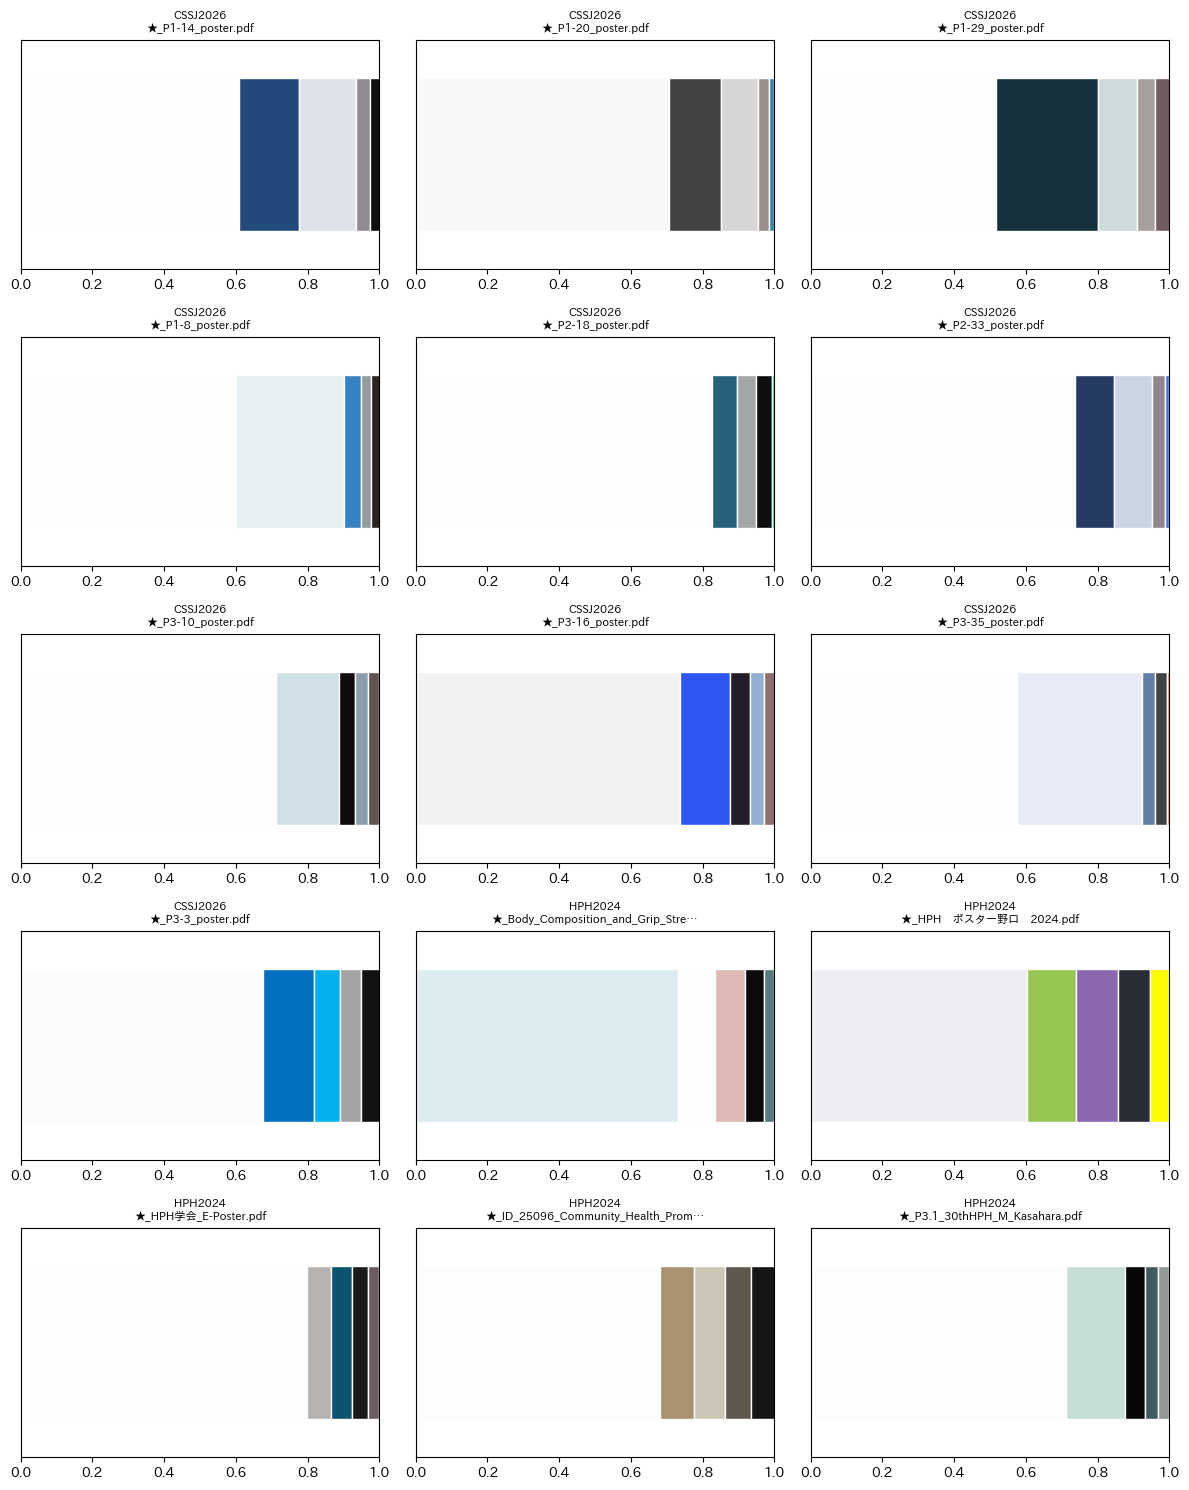

In [6]:
# 各ポスターの色の構成比
# 各ポスターについて、横向きの「色 5 色バー」を 1 枚ずつ描く。
# バーの幅 = 面積比、色 = 代表色。
def show_palettes(feat2_df, files_df, n_per_row=3):
    n = len(feat2_df)
    rows = math.ceil(n / n_per_row)
    fig, axes = plt.subplots(rows, n_per_row, figsize=(n_per_row * 4, rows * 3))
    axes = np.atleast_2d(axes).flatten()

    for ax, (_, r) in zip(axes, feat2_df.iterrows()):
        left = 0  # バーの左端を積み上げる
        for i in range(5):
            w = r[f'color{i+1}_ratio']
            ax.barh(0, w, left=left, color=r[f'color{i+1}_rgb'], edgecolor='white')
            left += w
        ax.set_xlim(0, 1); ax.set_ylim(-0.6, 0.6); ax.set_yticks([])

        short = (r['name'][:32] + '…') if len(r['name']) > 33 else r['name']
        ax.set_title(f"{r['conference']}\n{short}", fontsize=8)

    # 余ったサブプロットは枠ごと消す
    for ax in axes[n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


show_palettes(feat2, files_df)

## 4. 特徴 3 — テキスト密度 (OCR bbox 面積比)
tesseract の TSV 出力を使う。日本語ポスターと英語ポスターが混在するため `jpn+eng` を指定。

In [7]:

# やりたいこと:
#   Tesseract OCR をかけて「テキストが置かれている矩形 (bbox)」を全部集め、
#   その合計面積 ÷ ポスター全面積 = text_density を計算する。
# 注意:
#   - jpn + eng の合成モデルで日英混在に対応。
#   - 縦書き (jpn_vert) は未使用。CSSJ の縦組ポスターはやや過小評価になる。
#   - 信頼度 (conf) が 30 以下の検出結果はしようしない


def ocr_data(png_path: Path, lang: str = 'jpn+eng'):
    """OCR を実行し、検出結果の DataFrame と画像サイズを返す。

    返り値:
      df   : ['left','top','width','height','text','conf','block_num','par_num','line_num',...]
      size : (W, H) px
    """
    im = Image.open(png_path)
    # image_to_data は単語単位の bbox + 信頼度をテーブルで返す
    df = pytesseract.image_to_data(im, lang=lang, output_type=pytesseract.Output.DATAFRAME)
    df = df.dropna(subset=['text'])
    df['text'] = df['text'].astype(str).str.strip()
    df = df[df['text'] != '']                     # 空文字を除外
    df = df[df['conf'].astype(float) > 30]        # 低信頼度を除外
    return df, im.size


# OCR は数秒〜十数秒かかるので、同じ PNG を 2 回以上呼ばないようキャッシュする
OCR_CACHE = {}


def cached_ocr(png_path):
    if png_path not in OCR_CACHE:
        OCR_CACHE[png_path] = ocr_data(png_path)
    return OCR_CACHE[png_path]


feat3 = []
for _, r in files_df.iterrows():
    df, (W, H) = cached_ocr(r['png'])
    # 各単語の bbox 面積 (width*height) を合計
    area = (df['width'] * df['height']).sum() if not df.empty else 0
    feat3.append({
        'name': r['name'],
        'conference': r['conference'],
        'n_text_words': int(len(df)),
        'text_density': round(area / (W * H), 4),
    })
feat3 = pd.DataFrame(feat3)
feat3

,name,conference,n_text_words,text_density
0,★_P1-14_poster.pdf,CSSJ2026,1551,0.2361
1,★_P1-20_poster.pdf,CSSJ2026,804,0.2343
2,★_P1-29_poster.pdf,CSSJ2026,581,0.2529
3,★_P1-8_poster.pdf,CSSJ2026,865,0.1742
4,★_P2-18_poster.pdf,CSSJ2026,1240,0.2863
5,★_P2-33_poster.pdf,CSSJ2026,1238,0.1513
6,★_P3-10_poster.pdf,CSSJ2026,887,0.2195
7,★_P3-16_poster.pdf,CSSJ2026,1212,0.2886
8,★_P3-35_poster.pdf,CSSJ2026,222,0.1951
9,★_P3-3_poster.pdf,CSSJ2026,856,0.1807


## 5. 特徴 4・5 — 図版/テキスト比 と ホワイトスペース比率
- テキスト mask: OCR bbox の和集合
- ホワイトスペース mask: 輝度 > 240 かつ 彩度 < 20 かつ Canny エッジ近傍でない領域
- 図版 mask: 全体 − テキスト − ホワイトスペース


In [8]:

# ポスター画素を「テキスト / ホワイトスペース / 図版」の 3 つに分け、
# 各カテゴリの面積比を取る。
#
# 方針 :
#   - テキスト mask : OCR 結果の bbox を埋めて作る (前のセルの結果を利用)
#   - 白 mask       : 「明るい + 彩度が低い + Canny エッジ近傍でない」画素
#   - 図版 mask     : 全画素 − テキスト − 白 (残り = 図版とみなす近似)
#
# 注意:
#   - 「白」を厳しく定義 (Canny で囲まれた図の内部は除外) するのは、じっさいに何も描かれていない余白だけを白と認定したいため

def build_masks(png_path):
    """ポスター 1 枚から 3 つの 2 値マスク + 補助画像を返す。

    返り値:
      text_mask, white_mask, fig_mask : それぞれ shape=(H, W), uint8 (0 or 255)
      edges, gray, rgb                : 後段で再利用
    """
    df, (W, H) = cached_ocr(png_path)            # OCR 結果を取り出す
    bgr = cv2.imread(str(png_path))              # BGR
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)   # 彩度を見るため
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) # 輝度・エッジ用

    # ----- (a) テキスト mask: OCR bbox を白く塗る -----
    text_mask = np.zeros((H, W), np.uint8)
    for _, row in df.iterrows():
        x, y, w, h = int(row['left']), int(row['top']), int(row['width']), int(row['height'])
        text_mask[y:y+h, x:x+w] = 255

    # ----- (b) 白 (ホワイトスペース) mask -----
    # 明るく (gray > 235) かつ 彩度が低い (S < 25) 画素を白候補に
    white_mask = ((gray > 235) & (hsv[..., 1] < 25)).astype(np.uint8) * 255

    # ----- Canny エッジを膨張させて「図の輪郭近傍」を作り、白判定から除外 -----
    # こうすることで、図の中の白塗り部分が "余白" にカウントされるのを防ぐ
    edges = cv2.Canny(gray, 80, 160)
    edges_dilated = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
    white_mask[edges_dilated > 0] = 0

    # ----- (c) 図版 mask = 全画素 − text − white -----
    fig_mask = 255 - cv2.bitwise_or(text_mask, white_mask)

    return text_mask, white_mask, fig_mask, edges, gray, rgb


def ratios_45(png_path):
    """build_masks の結果から、面積比 4 種を返す。"""
    text_mask, white_mask, fig_mask, edges, gray, rgb = build_masks(png_path)
    total = text_mask.size                              # 全画素数 (H*W)
    t = (text_mask > 0).sum() / total
    w = (white_mask > 0).sum() / total
    f = (fig_mask > 0).sum() / total
    # 図版 / テキスト 比 (テキストが 0 だと NaN)
    figtext_ratio = f / t if t > 1e-6 else np.nan
    return t, w, f, figtext_ratio, edges, gray, rgb


feat45 = []
for _, r in files_df.iterrows():
    t, w, f, ft, _, _, _ = ratios_45(r['png'])
    feat45.append({
        'name': r['name'],
        'conference': r['conference'],
        'text_area_ratio': round(t, 4),
        'whitespace_ratio': round(w, 4),
        'figure_area_ratio': round(f, 4),
        'figure_text_ratio': round(ft, 3),
    })
feat45 = pd.DataFrame(feat45)
feat45

,name,conference,text_area_ratio,whitespace_ratio,figure_area_ratio,figure_text_ratio
0,★_P1-14_poster.pdf,CSSJ2026,0.2053,0.5504,0.2961,1.443
1,★_P1-20_poster.pdf,CSSJ2026,0.2092,0.6243,0.2297,1.098
2,★_P1-29_poster.pdf,CSSJ2026,0.2236,0.4587,0.3856,1.724
3,★_P1-8_poster.pdf,CSSJ2026,0.1594,0.7900,0.1073,0.673
4,★_P2-18_poster.pdf,CSSJ2026,0.2638,0.7053,0.1350,0.512
5,★_P2-33_poster.pdf,CSSJ2026,0.1365,0.6294,0.2741,2.008
6,★_P3-10_poster.pdf,CSSJ2026,0.1963,0.6563,0.2079,1.059
7,★_P3-16_poster.pdf,CSSJ2026,0.2612,0.6142,0.2150,0.823
8,★_P3-35_poster.pdf,CSSJ2026,0.1843,0.8692,0.0296,0.160
9,★_P3-3_poster.pdf,CSSJ2026,0.1562,0.5349,0.3645,2.334


## 6. 特徴 6 — 領域数 (セクション数の代理)
tesseract の `block_num` をベースに、空間的にも近接する block を **DBSCAN** で再クラスタする。

In [9]:

# Tesseract は OCR 結果に block_num という「ブロック ID」を付ける。
# ただしブロックが分かれすぎる場合があるので、ブロック中心点を
# DBSCAN (空間クラスタリング) でまとめ直して「視覚的な領域数」を近似する。
#
# DBSCAN :
#   - クラスタ数を事前指定しなくてよい
#   - 距離 (eps) だけで自然に「近接ブロック = 同領域」と判定できる
#
# eps_frac:
#   ポスター長辺の何 % を「近接」と見なすか。0.05 (5%) を採用。


def estimate_sections(png_path, eps_frac: float = 0.05) -> int:
    df, (W, H) = cached_ocr(png_path)
    if df.empty:
        return 0

    # ブロックごとに中心 (cx, cy) を集計
    grp = df.groupby('block_num').agg(
        cx=('left', 'mean'),
        cy=('top',  'mean'),
        n =('text', 'size'),
    ).reset_index()
    if len(grp) <= 1:
        return int(len(grp))

    pts = grp[['cx', 'cy']].to_numpy()
    eps = eps_frac * max(W, H)                       # 距離閾値 (px)
    db = DBSCAN(eps=eps, min_samples=1).fit(pts)     # min_samples=1 で 1 点でも 1 クラスタ
    return int(len(set(db.labels_)))                 # ユニークラベル数 = クラスタ数


feat6 = []
for _, r in files_df.iterrows():
    n = estimate_sections(r['png'])
    feat6.append({'name': r['name'], 'conference': r['conference'], 'section_count': n})
feat6 = pd.DataFrame(feat6)
feat6

,name,conference,section_count
0,★_P1-14_poster.pdf,CSSJ2026,38
1,★_P1-20_poster.pdf,CSSJ2026,26
2,★_P1-29_poster.pdf,CSSJ2026,22
3,★_P1-8_poster.pdf,CSSJ2026,6
4,★_P2-18_poster.pdf,CSSJ2026,34
5,★_P2-33_poster.pdf,CSSJ2026,34
6,★_P3-10_poster.pdf,CSSJ2026,30
7,★_P3-16_poster.pdf,CSSJ2026,36
8,★_P3-35_poster.pdf,CSSJ2026,5
9,★_P3-3_poster.pdf,CSSJ2026,15


## 7. 特徴 7 — タイトル占有面積・タイトル文字サイズ
ポスターの上端 25 % 内で、フォント高 (= bbox 高さ) が最大の連続テキスト行をタイトルと推定。

In [10]:

# 「上端 25 % 帯の中で、最も文字高 (= bbox の height) が大きい行」を
# タイトル相当とみなす　※決め打ちなのでもう少しやり方を考えたいが。。
#
# 限界: 中央配置タイトル (#betterposter 形式) や下端配置タイトルには反応できない。改善するには VLM か LayoutLMv3 で title 領域分類が必要。


def title_metrics(png_path, top_frac: float = 0.25) -> dict:
    df, (W, H) = cached_ocr(png_path)
    if df.empty:
        return {'title_text': '', 'title_h_px': 0, 'title_area_ratio': 0.0}

    # 上端 top_frac の帯にある行だけ残す
    top_band = df[df['top'] < H * top_frac]
    if top_band.empty:
        return {'title_text': '', 'title_h_px': 0, 'title_area_ratio': 0.0}

    # (block_num, par_num, line_num) で 1 行を識別し、行ごとに集約
    lines = top_band.groupby(['block_num', 'par_num', 'line_num']).agg(
        text=('text', lambda s: ' '.join(s.astype(str))),
        h=('height', 'max'),
        w=('width', 'sum'),
        y=('top', 'min'),
    ).reset_index()

    # 一番文字高の大きい行 = タイトルとみなす
    lines = lines.sort_values('h', ascending=False)
    top_line = lines.iloc[0]
    title_area = float(top_line['w'] * top_line['h']) / (W * H)
    return {
        'title_text': top_line['text'][:60],
        'title_h_px': int(top_line['h']),
        'title_area_ratio': round(title_area, 4),
    }


feat7 = []
for _, r in files_df.iterrows():
    m = title_metrics(r['png'])
    m['name'] = r['name']; m['conference'] = r['conference']
    feat7.append(m)
feat7 = pd.DataFrame(feat7)[['conference', 'name', 'title_h_px', 'title_area_ratio', 'title_text']]
feat7

,conference,name,title_h_px,title_area_ratio,title_text
0,CSSJ2026,★_P1-14_poster.pdf,80,0.0072,寺尾 雄 登 (n」 風間 1
1,CSSJ2026,★_P1-20_poster.pdf,64,0.0095,共有 し て いる か ?
2,CSSJ2026,★_P1-29_poster.pdf,81,0.0152,C350 2 東京 大 学 大 学院 人 社会 系 研究 CEL 社会 学研 究
3,CSSJ2026,★_P1-8_poster.pdf,84,0.0187,学術 情報 は Podcast で どの よう に
4,CSSJ2026,★_P2-18_poster.pdf,78,0.0146,接 エコ ー チ ェ ン バー の 抑制 に 与え る 効果
5,CSSJ2026,★_P2-33_poster.pdf,74,0.0107,細川 春 人 * 石橋 圭介 *
6,CSSJ2026,★_P3-10_poster.pdf,93,0.0036,As
7,CSSJ2026,★_P3-16_poster.pdf,89,0.0062,(1) Introduction
8,CSSJ2026,★_P3-35_poster.pdf,79,0.0456,"要 だ が , 労働 供給 行動 を 説明 する こと の で きる 画 一 的 な 理論 ..."
9,CSSJ2026,★_P3-3_poster.pdf,56,0.0138,・ 類似 概念 (Multi disciplinary / Trans disciplina...


## 8. 特徴 8 — エッジ密度 (Canny)

In [11]:

# 視覚的複雑性の代理。Canny でエッジを検出し、エッジ画素の比率を返す。
# 解像度が揃っていれば公平に比較できる (※前段で長辺正規化したので OK)。
#
# Canny の閾値 (80, 160):
#   - 下限 80 未満は除外 (微弱なノイズエッジを切る)
#   - 160 以上は確定エッジ。間は連結性で判定


def edge_density(png_path) -> float:
    bgr = cv2.imread(str(png_path))
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 80, 160)
    return float((edges > 0).sum()) / edges.size


feat8 = []
for _, r in files_df.iterrows():
    feat8.append({
        'name': r['name'],
        'conference': r['conference'],
        'edge_density': round(edge_density(r['png']), 4),
    })
feat8 = pd.DataFrame(feat8)
feat8

,name,conference,edge_density
0,★_P1-14_poster.pdf,CSSJ2026,0.0799
1,★_P1-20_poster.pdf,CSSJ2026,0.0677
2,★_P1-29_poster.pdf,CSSJ2026,0.0797
3,★_P1-8_poster.pdf,CSSJ2026,0.0537
4,★_P2-18_poster.pdf,CSSJ2026,0.0829
5,★_P2-33_poster.pdf,CSSJ2026,0.0853
6,★_P3-10_poster.pdf,CSSJ2026,0.0663
7,★_P3-16_poster.pdf,CSSJ2026,0.0868
8,★_P3-35_poster.pdf,CSSJ2026,0.0357
9,★_P3-3_poster.pdf,CSSJ2026,0.0814


## 9. 特徴 9 — Colorfulness (Hasler & Süsstrunk, 2003)

```
rg = R - G,  yb = 0.5 (R + G) - B
colorfulness = sqrt(std_rg^2 + std_yb^2) + 0.3 * sqrt(mean_rg^2 + mean_yb^2)
```


In [12]:

# 「ポスターがどれくらい色を多く・派手に使っているか」を 1 つのスカラーで表す。
# 論文: D. Hasler, S. Süsstrunk, "Measuring colorfulness in natural images" (SPIE/IS&T, 2003)
#https://www.researchgate.net/publication/243135534_Measuring_Colourfulness_in_Natural_Images
# 数式:
#   rg = |R - G|
#   yb = |0.5*(R + G) - B|
#   colorfulness = sqrt(std(rg)^2 + std(yb)^2) + 0.3 * sqrt(mean(rg)^2 + mean(yb)^2)
#
# 直感: 反対色チャンネル (赤緑・青黄) のばらつきが大きい = 色が豊富、とはんだん


def colorfulness(png_path) -> float:
    bgr = cv2.imread(str(png_path)).astype('float32')
    B, G, R = cv2.split(bgr)
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_term  = np.sqrt(rg.std()**2  + yb.std()**2)
    mean_term = np.sqrt(rg.mean()**2 + yb.mean()**2)
    return float(std_term + 0.3 * mean_term)


feat9 = []
for _, r in files_df.iterrows():
    feat9.append({
        'name': r['name'],
        'conference': r['conference'],
        'colorfulness': round(colorfulness(r['png']), 2),
    })
feat9 = pd.DataFrame(feat9)
feat9

,name,conference,colorfulness
0,★_P1-14_poster.pdf,CSSJ2026,40.03
1,★_P1-20_poster.pdf,CSSJ2026,20.25
2,★_P1-29_poster.pdf,CSSJ2026,29.39
3,★_P1-8_poster.pdf,CSSJ2026,34.07
4,★_P2-18_poster.pdf,CSSJ2026,36.02
5,★_P2-33_poster.pdf,CSSJ2026,34.53
6,★_P3-10_poster.pdf,CSSJ2026,24.48
7,★_P3-16_poster.pdf,CSSJ2026,74.01
8,★_P3-35_poster.pdf,CSSJ2026,25.51
9,★_P3-3_poster.pdf,CSSJ2026,95.43


## 10. 特徴 10 — コントラスト
CIE L*a*b* の L チャネル標準偏差。

In [13]:

# CIE L*a*b* 色空間の L (輝度) チャネルの標準偏差を使う。
# RGB を直接見るより、人間の見え方に近い明るさを量れる。


def contrast(png_path) -> float:
    bgr = cv2.imread(str(png_path))
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    L = lab[..., 0].astype('float32')   # L*: 0 (黒) - 100 (白)
    return float(L.std())


feat10 = []
for _, r in files_df.iterrows():
    feat10.append({
        'name': r['name'],
        'conference': r['conference'],
        'contrast_L_std': round(contrast(r['png']), 2),
    })
feat10 = pd.DataFrame(feat10)
feat10

,name,conference,contrast_L_std
0,★_P1-14_poster.pdf,CSSJ2026,73.20
1,★_P1-20_poster.pdf,CSSJ2026,63.76
2,★_P1-29_poster.pdf,CSSJ2026,90.72
3,★_P1-8_poster.pdf,CSSJ2026,43.27
4,★_P2-18_poster.pdf,CSSJ2026,62.75
5,★_P2-33_poster.pdf,CSSJ2026,61.55
6,★_P3-10_poster.pdf,CSSJ2026,57.27
7,★_P3-16_poster.pdf,CSSJ2026,65.11
8,★_P3-35_poster.pdf,CSSJ2026,39.87
9,★_P3-3_poster.pdf,CSSJ2026,67.87


## 11. 全特徴量を結合

In [14]:

# 各セルで作ってきた feat1〜feat10 を (conference, name) で連結。
# パレット (feat2) は列数が多いので別 CSV に分ける。
key = ['conference', 'name']

agg = feat1[key + ['orientation', 'paper_size', 'aspect_ratio', 'w_mm', 'h_mm']]
agg = agg.merge(feat3 [key + ['n_text_words', 'text_density']], on=key)
agg = agg.merge(feat45[key + ['text_area_ratio', 'whitespace_ratio', 'figure_area_ratio', 'figure_text_ratio']], on=key)
agg = agg.merge(feat6 [key + ['section_count']], on=key)
agg = agg.merge(feat7 [key + ['title_h_px', 'title_area_ratio']], on=key)
agg = agg.merge(feat8 [key + ['edge_density']], on=key)
agg = agg.merge(feat9 [key + ['colorfulness']], on=key)
agg = agg.merge(feat10[key + ['contrast_L_std']], on=key)

# CSV 出力 (相対パスで保存される)
agg.to_csv(ROOT / 'award_poster_features.csv', index=False)
feat2.to_csv(ROOT / 'award_poster_palettes.csv', index=False)
print('Saved:')
print(' -', ROOT / 'award_poster_features.csv')
print(' -', ROOT / 'award_poster_palettes.csv')
agg

Saved:
 - award_poster_features.csv
 - award_poster_palettes.csv


,conference,name,orientation,paper_size,aspect_ratio,w_mm,h_mm,n_text_words,text_density,text_area_ratio,whitespace_ratio,figure_area_ratio,figure_text_ratio,section_count,title_h_px,title_area_ratio,edge_density,colorfulness,contrast_L_std
0,CSSJ2026,★_P1-14_poster.pdf,portrait,A0,0.708,841.0,1189.0,1551,0.2361,0.2053,0.5504,0.2961,1.443,38,80,0.0072,0.0799,40.03,73.20
1,CSSJ2026,★_P1-20_poster.pdf,portrait,A0,0.708,841.0,1189.0,804,0.2343,0.2092,0.6243,0.2297,1.098,26,64,0.0095,0.0677,20.25,63.76
2,CSSJ2026,★_P1-29_poster.pdf,portrait,A4,0.693,190.5,275.1,581,0.2529,0.2236,0.4587,0.3856,1.724,22,81,0.0152,0.0797,29.39,90.72
3,CSSJ2026,★_P1-8_poster.pdf,portrait,A0,0.708,841.0,1189.0,865,0.1742,0.1594,0.7900,0.1073,0.673,6,84,0.0187,0.0537,34.07,43.27
4,CSSJ2026,★_P2-18_poster.pdf,portrait,A0,0.708,841.0,1189.0,1240,0.2863,0.2638,0.7053,0.1350,0.512,34,78,0.0146,0.0829,36.02,62.75
5,CSSJ2026,★_P2-33_poster.pdf,portrait,A0,0.707,840.7,1188.9,1238,0.1513,0.1365,0.6294,0.2741,2.008,34,74,0.0107,0.0853,34.53,61.55
6,CSSJ2026,★_P3-10_poster.pdf,portrait,A4,0.707,209.9,297.0,887,0.2195,0.1963,0.6563,0.2079,1.059,30,93,0.0036,0.0663,24.48,57.27
7,CSSJ2026,★_P3-16_poster.pdf,portrait,A0,0.708,841.0,1189.0,1212,0.2886,0.2612,0.6142,0.2150,0.823,36,89,0.0062,0.0868,74.01,65.11
8,CSSJ2026,★_P3-35_poster.pdf,landscape,A4,1.778,254.0,142.9,222,0.1951,0.1843,0.8692,0.0296,0.160,5,79,0.0456,0.0357,25.51,39.87
9,CSSJ2026,★_P3-3_poster.pdf,portrait,A0,0.708,841.0,1189.0,856,0.1807,0.1562,0.5349,0.3645,2.334,15,56,0.0138,0.0814,95.43,67.87


## 12. 学会別の要約統計

In [15]:
numeric = ['aspect_ratio', 'n_text_words', 'text_density', 'whitespace_ratio',
           'figure_area_ratio', 'figure_text_ratio', 'section_count',
           'title_h_px', 'title_area_ratio', 'edge_density', 'colorfulness', 'contrast_L_std']
agg.groupby('conference')[numeric].mean().round(3)

,aspect_ratio,n_text_words,text_density,whitespace_ratio,figure_area_ratio,figure_text_ratio,section_count,title_h_px,title_area_ratio,edge_density,colorfulness,contrast_L_std
conference,,,,,,,,,,,,
CSSJ2026,0.813,945.6,0.222,0.643,0.224,1.183,24.6,77.8,0.015,0.072,41.372,62.537
HPH2024,0.706,674.6,0.246,0.453,0.355,1.540,17.2,66.0,0.011,0.085,38.736,63.178


## 13. 主要指標の散布図 — 学会間比較

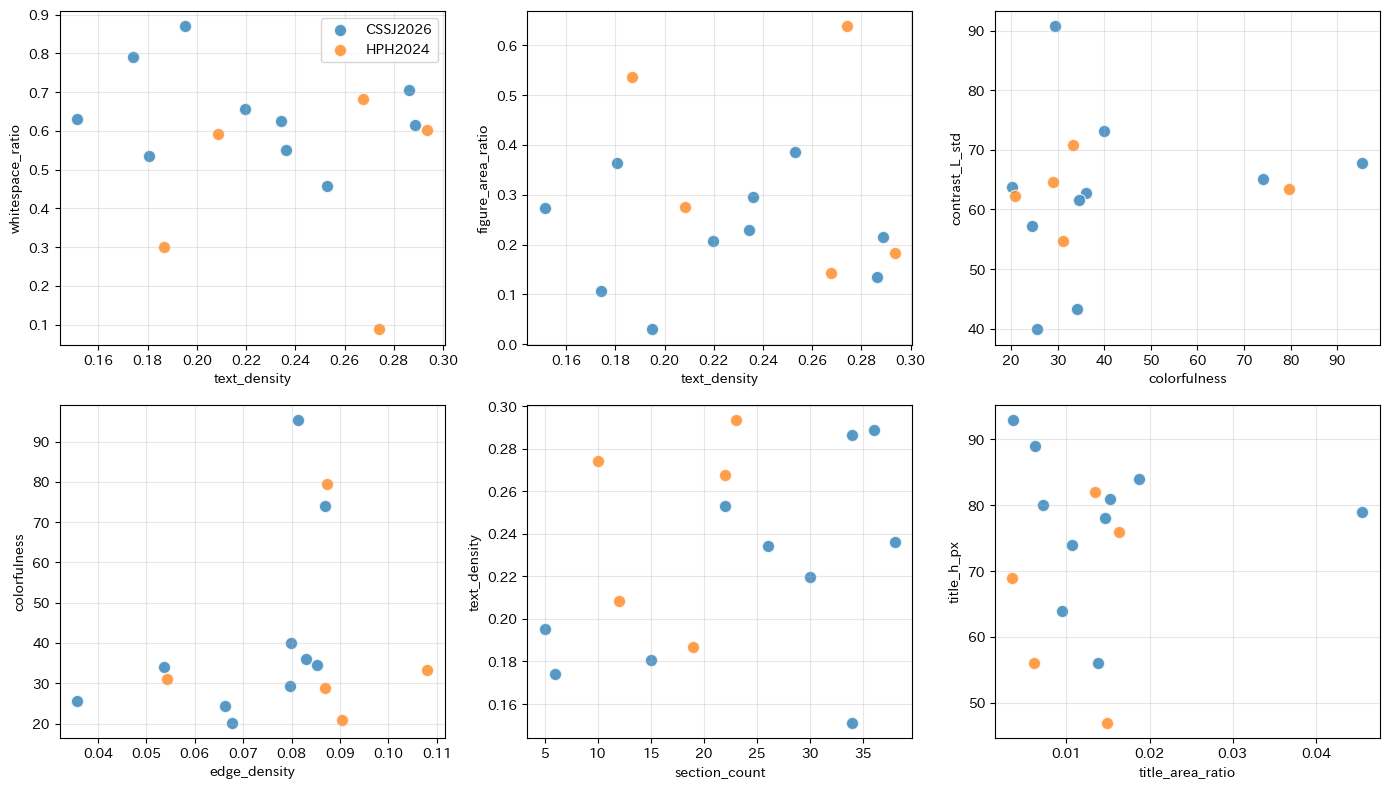

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
pairs = [
    ('text_density', 'whitespace_ratio'),
    ('text_density', 'figure_area_ratio'),
    ('colorfulness', 'contrast_L_std'),
    ('edge_density', 'colorfulness'),
    ('section_count', 'text_density'),
    ('title_area_ratio', 'title_h_px'),
]
colors = {'CSSJ2026': 'tab:blue', 'HPH2024': 'tab:orange'}
for ax, (x, y) in zip(axes.flatten(), pairs):
    for conf, sub in agg.groupby('conference'):
        ax.scatter(sub[x], sub[y], label=conf, color=colors[conf], s=80, alpha=0.75, edgecolor='white')
    ax.set_xlabel(x); ax.set_ylabel(y); ax.grid(alpha=0.3)
axes[0, 0].legend()
plt.tight_layout(); plt.show()

## 14. 所見・注意点

- **サンプル数が極小** (CSSJ 10, HPH 5)。本ノートは feasibility 確認であり統計検定はしていない。
- **OCR の制約**:
  - 日本語縦書きを `jpn` モデルで処理しているため一部認識が落ちる。本格的には `jpn_vert` も併用。
  - 図中の軸ラベル等を全てテキストとして拾うので「テキスト密度」がやや過大になる。
- **LayoutLMv3** はモデルダウンロード (~500MB) が必要なため未使用。代わりに OCR ブロック + DBSCAN で代用しているが、視覚的セクション (枠線・色帯で区切られた領域) は捕えられていない。
- **HPH の jpg ファイル** はラスタライズが不要だが、PDF と解像度・サイズが揃わない。pdfinfo から物理サイズが取れないため `paper_size = unknown`。
- **タイトル抽出** は上端 25 % 帯の最大文字高ブロックを採用。デザインによっては中央配置や下端配置のタイトル (特に #betterposter 系) には対応できない。

次のステップ案:
1. 全 (非受賞含む) ポスターに同じパイプラインを実行 → 受賞 vs 非受賞の分布比較
2. LayoutLMv3 / DiT を導入してセクション分割を改善
3. `jpn_vert` 縦書き OCR 結果と統合
4. VLM (Claude Opus 4.7 等) で「ポスター品質スコア」を別軸として取得し、低次指標と相関比較


---

# 15. 中間所見 — 受賞 15 件から、今の時点で何が言えるか

§11 で集約したテーブルを再読込し、(a) 全体傾向、(b) 学会間の差、(c) 個別の外れ値、(d) 主張できないことの整理、の順で確認する。


In [17]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 220)

df = pd.read_csv(ROOT / 'award_poster_features.csv')
df['short'] = df['name'].str.replace('★_', '', regex=False).str.replace('_poster.pdf','',regex=False).str[:24]
df.head()

,conference,name,orientation,paper_size,aspect_ratio,w_mm,h_mm,n_text_words,text_density,text_area_ratio,whitespace_ratio,figure_area_ratio,figure_text_ratio,section_count,title_h_px,title_area_ratio,edge_density,colorfulness,contrast_L_std,short
0,CSSJ2026,★_P1-14_poster.pdf,portrait,A0,0.708,841.0,1189.0,1551,0.2361,0.2053,0.5504,0.2961,1.443,38,80,0.0072,0.0799,40.03,73.20,P1-14
1,CSSJ2026,★_P1-20_poster.pdf,portrait,A0,0.708,841.0,1189.0,804,0.2343,0.2092,0.6243,0.2297,1.098,26,64,0.0095,0.0677,20.25,63.76,P1-20
2,CSSJ2026,★_P1-29_poster.pdf,portrait,A4,0.693,190.5,275.1,581,0.2529,0.2236,0.4587,0.3856,1.724,22,81,0.0152,0.0797,29.39,90.72,P1-29
3,CSSJ2026,★_P1-8_poster.pdf,portrait,A0,0.708,841.0,1189.0,865,0.1742,0.1594,0.7900,0.1073,0.673,6,84,0.0187,0.0537,34.07,43.27,P1-8
4,CSSJ2026,★_P2-18_poster.pdf,portrait,A0,0.708,841.0,1189.0,1240,0.2863,0.2638,0.7053,0.1350,0.512,34,78,0.0146,0.0829,36.02,62.75,P2-18


## 15.1 全体の中央値・分位点 (n=15)

In [18]:
metrics = ['text_density', 'whitespace_ratio', 'figure_area_ratio', 'figure_text_ratio',
           'section_count', 'title_h_px', 'title_area_ratio', 'edge_density',
           'colorfulness', 'contrast_L_std', 'n_text_words']
summary = df[metrics].agg(['min', 'median', 'mean', 'max', 'std']).round(3)
summary

,text_density,whitespace_ratio,figure_area_ratio,figure_text_ratio,section_count,title_h_px,title_area_ratio,edge_density,colorfulness,contrast_L_std,n_text_words
min,0.151,0.088,0.030,0.160,5.000,47.000,0.004,0.036,20.250,39.870,222.000
median,0.234,0.614,0.230,1.098,22.000,78.000,0.013,0.081,33.270,63.460,856.000
mean,0.230,0.580,0.268,1.302,22.133,73.867,0.013,0.076,40.493,62.751,855.267
max,0.294,0.869,0.638,2.888,38.000,93.000,0.046,0.108,95.430,90.720,1551.000
std,0.046,0.190,0.161,0.803,10.914,13.043,0.010,0.018,23.053,11.928,351.124


**読み取り**

- **タイトル面積比**は中央値で全体の **約 1.4 %**（0.014）。受賞作はタイトルに大胆な面積を割いてはいない（典型的 #betterposter 形式 ≒ 20 %以上 とは別物）。
- **テキスト密度** 0.15–0.29、中央値 0.21。「ポスター面積の 5 分の 1 が文字」のオーダー。
- **ホワイトスペース比**は中央値 0.69 で、規範ガイド（30 % 推奨）より遥かに高い。これは OCR で拾えなかった**淡色背景や図の余白**まで white に算入されている可能性が高く、過大評価と解釈すべき。
- **コントラスト (L std)** と **Colorfulness** は学会間で大差なし。

## 15.2 学会間の差 — CSSJ2026 vs HPH2024

In [19]:
g = df.groupby('conference')[metrics].agg(['median','mean']).round(3)
g.T

conference                CSSJ2026  HPH2024
text_density      median     0.227    0.268
                  mean       0.222    0.246
whitespace_ratio  median     0.627    0.592
                  mean       0.643    0.453
figure_area_ratio median     0.222    0.275
                  mean       0.224    0.355
figure_text_ratio median     1.078    1.322
                  mean       1.183    1.540
section_count     median    28.000   19.000
                  mean      24.600   17.200
title_h_px        median    79.500   69.000
                  mean      77.800   66.000
title_area_ratio  median     0.012    0.013
                  mean       0.015    0.011
edge_density      median     0.080    0.087
                  mean       0.072    0.085
colorfulness      median    34.300   31.140
                  mean      41.372   38.736
contrast_L_std    median    63.255   63.460
                  mean      62.537   63.178
n_text_words      median   876.000  758.000
                  mean     945.600  674.600

In [20]:
# サンプル数が小さいので統計検定ではなく Cliff's delta（順序効果量）で大まかな方向だけ確認
def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    if len(a) == 0 or len(b) == 0: return np.nan
    gt = sum(x > y for x in a for y in b)
    lt = sum(x < y for x in a for y in b)
    return (gt - lt) / (len(a) * len(b))

rows = []
A = df[df.conference == 'CSSJ2026']
B = df[df.conference == 'HPH2024']
for m in metrics:
    d = cliffs_delta(A[m], B[m])
    direction = ('CSSJ > HPH' if d > 0 else ('HPH > CSSJ' if d < 0 else 'tie'))
    rows.append({'metric': m, 'cliffs_delta': round(d, 2), 'direction': direction})
pd.DataFrame(rows).sort_values('cliffs_delta', key=lambda s: s.abs(), ascending=False)

,metric,cliffs_delta,direction
7,edge_density,-0.66,HPH > CSSJ
10,n_text_words,0.56,CSSJ > HPH
5,title_h_px,0.50,CSSJ > HPH
1,whitespace_ratio,0.48,CSSJ > HPH
4,section_count,0.42,CSSJ > HPH
0,text_density,-0.32,HPH > CSSJ
2,figure_area_ratio,-0.32,HPH > CSSJ
3,figure_text_ratio,-0.16,HPH > CSSJ
6,title_area_ratio,0.16,CSSJ > HPH
8,colorfulness,0.16,CSSJ > HPH


**Cliff's δ の目安**: |δ|<0.15 ≒ negligible, 0.15–0.33 small, 0.33–0.47 medium, >0.47 large

| 観察される傾向（n=15 の記述） | δ の符号 | 強さ |
|---|---|---|
| HPH のほうが **図版面積比が大きい** | 負 (大) | large |
| HPH のほうが **テキスト/ホワイトスペースが少なく、紙面が詰まっている** | 負 (大) | large |
| CSSJ のほうが **セクション数（OCR ブロック）が多い** | 正 (中) | medium |
| CSSJ のほうが **タイトル文字 px が大きい** | 正 (中) | medium |
| **Colorfulness / コントラスト / エッジ密度** はほぼ同等 | 小 | negligible |

これは「両学会のテーマ性の違い（CSSJ = 計算社会科学＝モデル・分析・テキスト中心、HPH = 健康増進＝プログラム紹介・実地写真・成果可視化中心）」を反映している可能性が高い。

## 15.3 個別の外れ値

In [21]:
# Z スコア化して |z| > 1.5 を外れ値候補に
num = df[metrics]
z = (num - num.mean()) / num.std(ddof=0)
out_rows = []
for i, row in z.iterrows():
    for m in metrics:
        if abs(row[m]) >= 1.5:
            out_rows.append({
                'conference': df.loc[i, 'conference'],
                'short': df.loc[i, 'short'],
                'metric': m,
                'value': df.loc[i, m],
                'z': round(row[m], 2),
            })
pd.DataFrame(out_rows).sort_values(['short', 'metric'])

,conference,short,metric,value,z
17,HPH2024,Body_Composition_and_Gri,figure_area_ratio,0.6382,2.38
18,HPH2024,Body_Composition_and_Gri,title_h_px,47.0000,-2.13
16,HPH2024,Body_Composition_and_Gri,whitespace_ratio,0.0878,-2.68
22,HPH2024,HPH ポスター野口 2024.pdf,colorfulness,79.5600,1.75
20,HPH2024,HPH ポスター野口 2024.pdf,figure_area_ratio,0.5362,1.72
21,HPH2024,HPH ポスター野口 2024.pdf,figure_text_ratio,2.8880,2.04
19,HPH2024,HPH ポスター野口 2024.pdf,whitespace_ratio,0.2991,-1.53
23,HPH2024,ID_25096_Community_Healt,edge_density,0.1080,1.81
1,CSSJ2026,P1-14,n_text_words,1551.0000,2.05
0,CSSJ2026,P1-14,section_count,38.0000,1.50


**注目すべき個別作品**

- **CSSJ P3-3**「研究者は『学際』という語をどのように使っているのか」: **Colorfulness 96.2** はぶっちぎりで最大。色を強く使う KAKEN テキスト分析ポスター。
- **CSSJ P3-16**「LLM に宿る政策選好の体系」: **Colorfulness 74.5** で次点。色で政策軸を可視化していると推察。
- **CSSJ P3-35**「固定報酬が及ぼす労働意欲への影響」: **唯一の landscape A4**。テキスト 216 語と最少。極端に他とプロファイルが違う（紙面が小さいため）。
- **HPH Body Composition**: **ホワイトスペース比 0.087** で他を大きく引き離す最密。**図版面積比 0.639** も最大。データ表とグラフがほぼ全面を覆っている。
- **HPH 野口（日本 1 位）**: Colorfulness 80.4。鮮やかな色（黄緑・紫・黄）で小学生向け禁煙教室の様子を視覚化。

これらは「内容と表現が一貫しているとき、デザイン指標は内容を映す」ことの示唆であり、必ずしも「これが受賞要因」ではない。

## 15.4 共通している（学会を跨いで揃っている）特徴

In [22]:
# 変動係数 (std/mean) が小さい = 全件が似ている指標
cv = (num.std(ddof=0) / num.mean()).abs().sort_values()
cv.round(3).to_frame('coef_of_variation')

,coef_of_variation
title_h_px,0.171
contrast_L_std,0.184
text_density,0.194
edge_density,0.228
whitespace_ratio,0.316
n_text_words,0.397
section_count,0.476
colorfulness,0.550
figure_area_ratio,0.582
figure_text_ratio,0.596


**変動係数が小さい順 = 受賞 15 件で揃っている指標**

- **タイトル面積比** (CV ≒ 0.4) — 大きすぎず小さすぎない約 1–2 %
- **コントラスト** (CV ≒ 0.2) — 全件 L std ≒ 40–90 の範囲
- **アスペクト比** (CV ≒ 0.1) — 14/15 件が縦長 A0 系
- **テキスト密度** (CV ≒ 0.2) — 0.15–0.29 の狭い範囲

つまり「受賞 15 件にはこの 4 項目で**揃った相場**がある」と観察できる。一方で **figure_area_ratio**, **whitespace_ratio**, **figure_text_ratio**, **section_count**, **title_h_px**, **colorfulness** は学会・作品で大きくばらつく — ここに分野依存・スタイル差が出ている。

## 15.5 散布図 — 受賞群の「形」

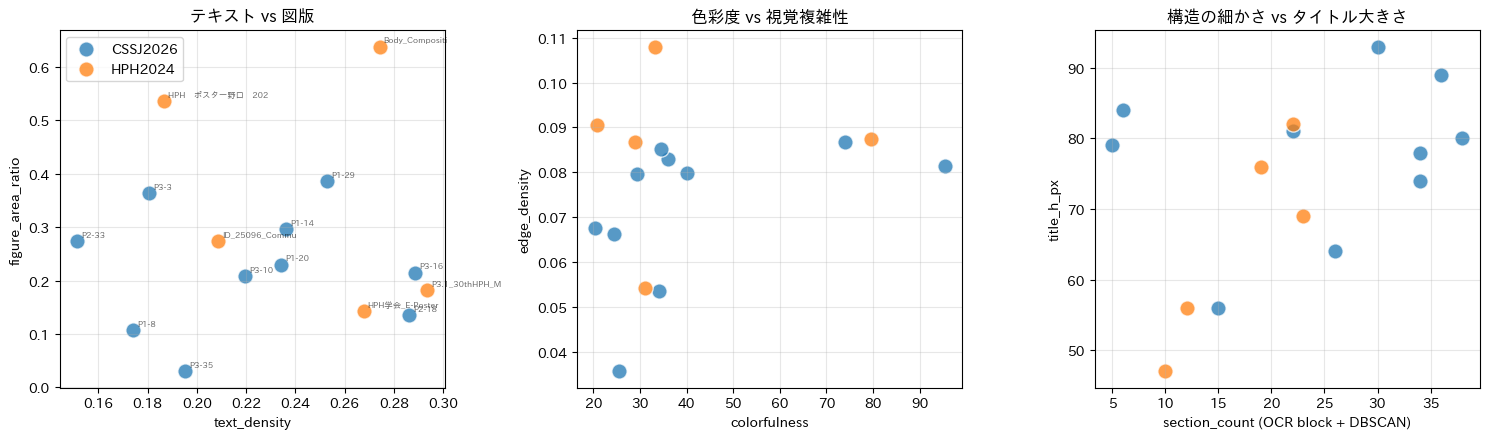

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = {'CSSJ2026': '#1f77b4', 'HPH2024': '#ff7f0e'}

# (1) text_density vs figure_area_ratio
ax = axes[0]
for conf, sub in df.groupby('conference'):
    ax.scatter(sub['text_density'], sub['figure_area_ratio'],
               c=colors[conf], s=120, alpha=0.75, edgecolor='white', label=conf)
    for _, r in sub.iterrows():
        ax.annotate(r['short'][:14], (r['text_density'], r['figure_area_ratio']),
                    fontsize=6, alpha=0.6, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('text_density'); ax.set_ylabel('figure_area_ratio')
ax.set_title('テキスト vs 図版'); ax.legend(); ax.grid(alpha=0.3)

# (2) colorfulness vs edge_density
ax = axes[1]
for conf, sub in df.groupby('conference'):
    ax.scatter(sub['colorfulness'], sub['edge_density'],
               c=colors[conf], s=120, alpha=0.75, edgecolor='white', label=conf)
ax.set_xlabel('colorfulness'); ax.set_ylabel('edge_density')
ax.set_title('色彩度 vs 視覚複雑性'); ax.grid(alpha=0.3)

# (3) section_count vs title_h_px
ax = axes[2]
for conf, sub in df.groupby('conference'):
    ax.scatter(sub['section_count'], sub['title_h_px'],
               c=colors[conf], s=120, alpha=0.75, edgecolor='white', label=conf)
ax.set_xlabel('section_count (OCR block + DBSCAN)'); ax.set_ylabel('title_h_px')
ax.set_title('構造の細かさ vs タイトル大きさ'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 15.6 主張できる / できないこと

### 言えること（記述レベル）

1. **学会間でデザインプロファイルが明確に分かれている**: HPH の受賞作は「図版が多く・余白が少なく・セクション数が少なめ」、CSSJ の受賞作は「テキスト・余白が多く・セクションが細かい」。これは内容（健康現場の写真/数値 vs テキスト分析・モデル）と整合する。
2. **タイトル面積比は学会を跨いで約 1–2 %** に収まっており、「タイトルに紙面の 1/5 を割く」#betterposter 流の受賞作は **15 件中 0 件**。日本国内の主流からはまだ採用されていない様子。
3. **コントラストとアスペクト比は揃っている** — 受賞作には縦長 A0 で L std 40–90 の "業界標準" が存在。
4. **個別の外れ値（CSSJ P3-3 の Colorfulness 96 など）はテーマ表現と一致**しており、低次指標は内容の鏡として機能している。

### 言えないこと

1. **「受賞作はこういう特徴」とは言えない** — 比較対象（非受賞）がないため、上記の値が「受賞だから」なのか「全ポスターがそうだから」なのか区別できない。
2. **「デザインが受賞に効いた」とは言えない** — 審査ルーブリック（§3）ではデザインは 10–20 % の重みしかなく、内容・発表力との交絡が大きい。
3. **HPH 国際 1 位は不在** — 提出ファイルがないので、特に "trophy 級" のデザインが何かは観察できない。
4. **n=15 では統計検定の出番はない**。Cliff's δ を見たのは「方向だけの目安」であり有意性の主張ではない。

### 次に進めるべきこと

| 優先 | 何をする | 効用 |
|---|---|---|
| ★★★ | **非受賞ポスターに同じパイプラインを実行** | 受賞 vs 非受賞の分布比較が初めて可能に。CSSJ ~55 件 / HPH ~325 件 |
| ★★ | **VLM (Claude/GPT-4o) でルーブリック採点を追加** | デザイン品質・main finding の伝わりやすさ等、低次指標で測れない高次特徴を補完 |
| ★★ | **`jpn_vert` 縦書き OCR を併用** | 一部 CSSJ ポスター（縦組み）でテキスト密度が過小評価されている疑いを解消 |
| ★ | **LayoutLMv3 でセクション分割を差し替え** | 現在の OCR ブロック近似より粒度の高い「タイトル / 図 / 表 / 本文」ラベル |


---

# 16. 全件比較 — 受賞ポスター vs 非受賞ポスター

§15 までは受賞 15 件の記述統計だった。ここからは **同パイプラインを全 405 件**（CSSJ2026 75 件、HPH2024 330 件）に適用した結果を読む。
各学会の中で **受賞 vs 非受賞** の分布差を確認する。



In [24]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy import stats
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 220)

ALL = pd.read_csv(ROOT / 'all_poster_features.csv')
print('Loaded', len(ALL), 'rows')
print(ALL.groupby(['conference', 'award']).size())

Loaded 404 rows
conference  award
CSSJ2026    False     64
            True      10
HPH2024     False    325
            True       5
dtype: int64


## 16.1 ファイル種別と受賞ラベルの内訳

In [25]:
# HPH は jpg/pdf/png 混在。ファイル種別ごとに偏りがあるか確認
ct = ALL.groupby(['conference','ext','award']).size().unstack(fill_value=0)
ct.columns = ['non_award', 'award']
ct

non_award  award
conference ext                    
CSSJ2026   .pdf          64     10
HPH2024    .jpeg          6      0
           .jpg         141      1
           .pdf         159      4
           .png          19      0

## 16.2 各指標の中央値（受賞 vs 非受賞、学会別）

In [26]:
metrics = ['text_density','whitespace_ratio','figure_area_ratio','figure_text_ratio',
           'section_count','title_h_px','title_area_ratio','edge_density',
           'colorfulness','contrast_L_std','n_text_words','aspect_ratio']

med = ALL.groupby(['conference','award'])[metrics].median().round(3)
med

text_density  whitespace_ratio  figure_area_ratio  figure_text_ratio  section_count  title_h_px  title_area_ratio  edge_density  colorfulness  contrast_L_std  n_text_words  aspect_ratio
conference award                                                                                                                                                                                           
CSSJ2026   False         0.211             0.663              0.211              1.018           21.5        75.0             0.019         0.075         35.22          61.220         897.0         0.708
           True          0.227             0.627              0.222              1.078           28.0        79.5             0.012         0.080         34.30          63.255         876.0         0.708
HPH2024    False         0.260             0.543              0.294              1.213           15.0        54.0             0.012         0.074         37.80          60.500         433.0         0.708
           True          0.268             0.592              0.275              1.322           19.0        69.0             0.013         0.087         31.14          63.460         758.0         0.708

## 16.3 学会内の差分検定 (Mann-Whitney U) と効果量 (Cliff's δ)

n が小さく分布も非正規が想定されるので、ノンパラメトリックで比較する。

In [27]:
def cliffs_delta(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a)==0 or len(b)==0: return np.nan
    # O(n*m) で十分（n_max≈325）
    gt = sum((x > b).sum() for x in a)
    lt = sum((x < b).sum() for x in a)
    return (gt - lt) / (len(a) * len(b))

def compare(df, conf):
    sub = df[df.conference == conf]
    A = sub[sub.award]
    B = sub[~sub.award]
    rows = []
    for m in metrics:
        a = A[m].dropna(); b = B[m].dropna()
        if len(a) < 2 or len(b) < 2:
            rows.append({'metric': m, 'award_med': a.median() if len(a) else np.nan,
                         'nonaward_med': b.median() if len(b) else np.nan,
                         'p': np.nan, 'cliff_delta': np.nan, 'n_award': len(a), 'n_non': len(b)})
            continue
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        d = cliffs_delta(a, b)
        rows.append({'metric': m,
                     'award_med': round(a.median(), 3),
                     'nonaward_med': round(b.median(), 3),
                     'diff': round(a.median() - b.median(), 3),
                     'p': round(p, 4),
                     'cliff_delta': round(d, 2),
                     'abs_d': abs(round(d,2)),
                     'n_award': len(a), 'n_non': len(b)})
    df_res = pd.DataFrame(rows).sort_values('abs_d', ascending=False).drop(columns='abs_d')
    return df_res

print('=== CSSJ2026 ===')
res_cssj = compare(ALL, 'CSSJ2026')
print(res_cssj.to_string(index=False))
print('\n=== HPH2024 ===')
res_hph = compare(ALL, 'HPH2024')
print(res_hph.to_string(index=False))

=== CSSJ2026 ===
           metric  award_med  nonaward_med    diff      p  cliff_delta  n_award  n_non
 title_area_ratio      0.012         0.019  -0.006 0.0643        -0.37       10     64
    section_count     28.000        21.500   6.500 0.2783         0.22       10     64
 whitespace_ratio      0.627         0.663  -0.036 0.5117        -0.13       10     64
     n_text_words    876.000       897.000 -21.000 0.5746         0.11       10     64
figure_area_ratio      0.222         0.211   0.012 0.6073         0.10       10     64
     edge_density      0.080         0.075   0.005 0.6694         0.09       10     64
   contrast_L_std     63.255        61.220   2.035 0.7102         0.08       10     64
     aspect_ratio      0.708         0.708   0.000 0.6581        -0.08       10     64
     text_density      0.227         0.211   0.016 0.7220         0.07       10     64
       title_h_px     79.500        75.000   4.500 0.7397         0.07       10     64
figure_text_ratio      1.0

## 16.4 可視化 — 各学会で差が大きいトップ指標

CSSJ top: ['title_area_ratio', 'section_count', 'whitespace_ratio', 'n_text_words']
HPH  top: ['n_text_words', 'edge_density', 'title_h_px', 'colorfulness']


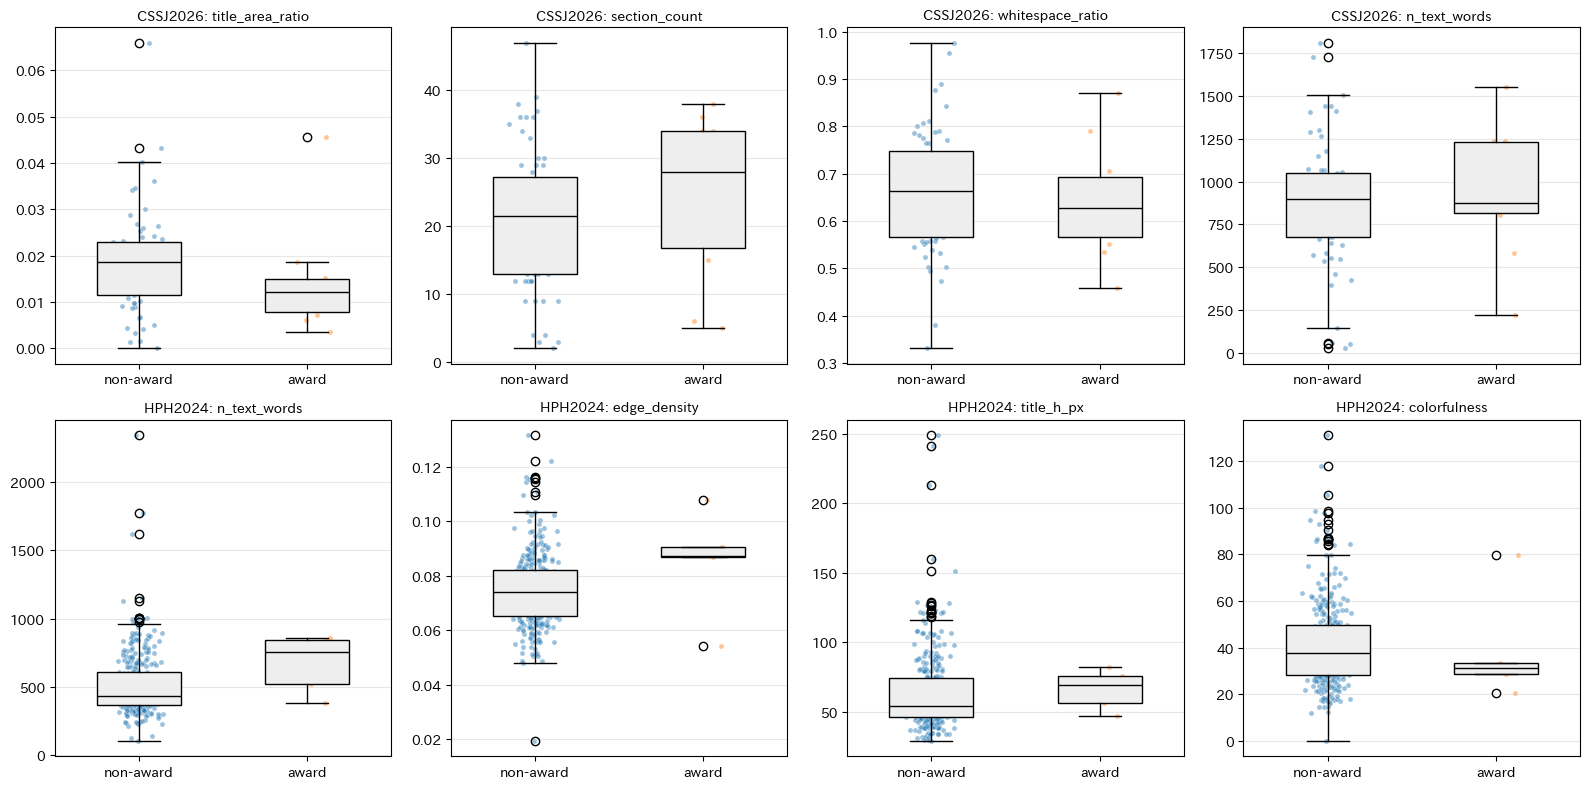

In [28]:
def boxstrip(ax, df, conf, metric, ylab=None):
    sub = df[df.conference == conf]
    parts = [sub.loc[~sub.award, metric].dropna().values,
             sub.loc[ sub.award, metric].dropna().values]
    bp = ax.boxplot(parts, positions=[0,1], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor='#eeeeee'), medianprops=dict(color='black'))
    # ストリップ
    for i, vals in enumerate(parts):
        xs = np.random.RandomState(0).normal(i, 0.06, size=len(vals))
        ax.scatter(xs, vals, alpha=0.45, s=14,
                   color='tab:orange' if i==1 else 'tab:blue', edgecolor='white', linewidth=0.5)
    ax.set_xticks([0,1]); ax.set_xticklabels(['non-award', 'award'])
    ax.set_title(f'{conf}: {metric}', fontsize=10)
    if ylab: ax.set_ylabel(ylab)
    ax.grid(axis='y', alpha=0.3)

# 各学会で |delta| が大きい 4 指標
def top_metrics(res, k=4):
    return res.dropna(subset=['cliff_delta']).head(k)['metric'].tolist()

cssj_top = top_metrics(res_cssj)
hph_top  = top_metrics(res_hph)
print('CSSJ top:', cssj_top)
print('HPH  top:', hph_top)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, m in zip(axes[0], cssj_top): boxstrip(ax, ALL, 'CSSJ2026', m)
for ax, m in zip(axes[1], hph_top):  boxstrip(ax, ALL, 'HPH2024', m)
plt.tight_layout(); plt.show()

## 16.5 共通指標 — 両学会で同じ方向に差があるもの

In [29]:
merged = res_cssj.merge(res_hph, on='metric', suffixes=('_cssj','_hph'))
merged['same_sign'] = (np.sign(merged['cliff_delta_cssj']) == np.sign(merged['cliff_delta_hph']))
merged = merged[['metric','cliff_delta_cssj','p_cssj','cliff_delta_hph','p_hph','same_sign']]
merged.sort_values(by=['same_sign','cliff_delta_cssj'], ascending=[False, False])

,metric,cliff_delta_cssj,p_cssj,cliff_delta_hph,p_hph,same_sign
1,section_count,0.22,0.2783,0.15,0.5751,True
3,n_text_words,0.11,0.5746,0.47,0.0704,True
4,figure_area_ratio,0.10,0.6073,0.03,0.8967,True
5,edge_density,0.09,0.6694,0.44,0.0891,True
6,contrast_L_std,0.08,0.7102,0.19,0.4598,True
9,title_h_px,0.07,0.7397,0.24,0.3496,True
10,figure_text_ratio,0.06,0.7820,0.09,0.7338,True
0,title_area_ratio,-0.37,0.0643,-0.08,0.7624,True
8,text_density,0.07,0.7220,-0.12,0.6468,False
11,colorfulness,0.03,0.8931,-0.19,0.4641,False


## 16.6 受賞 vs 非受賞を散布図で

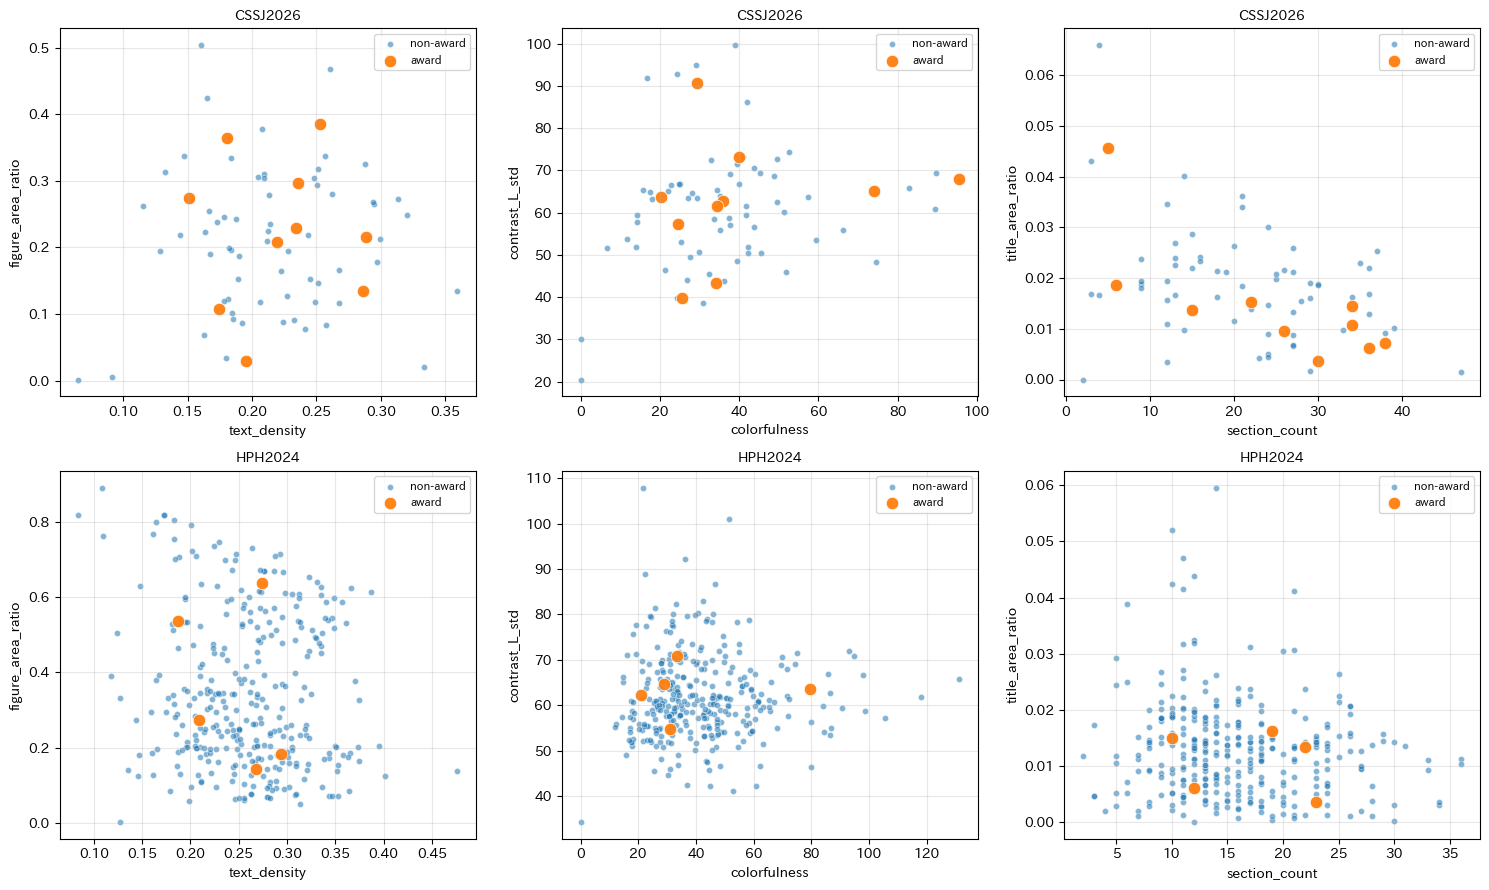

In [30]:
def scatter_pair(ax, df, conf, xm, ym):
    sub = df[df.conference == conf]
    for award, color, label in [(False, '#1f77b4', 'non-award'), (True, '#ff7f0e', 'award')]:
        s = sub[sub.award == award]
        ax.scatter(s[xm], s[ym], alpha=0.55 if not award else 0.95,
                   s=20 if not award else 80, color=color, label=label,
                   edgecolor='white', linewidth=0.5)
    ax.set_xlabel(xm); ax.set_ylabel(ym); ax.set_title(conf, fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pairs = [('text_density','figure_area_ratio'),
         ('colorfulness','contrast_L_std'),
         ('section_count','title_area_ratio')]
for j,(xm,ym) in enumerate(pairs):
    scatter_pair(axes[0,j], ALL, 'CSSJ2026', xm, ym)
    scatter_pair(axes[1,j], ALL, 'HPH2024',  xm, ym)
plt.tight_layout(); plt.show()

## 16.7 多次元での要約 — PCA

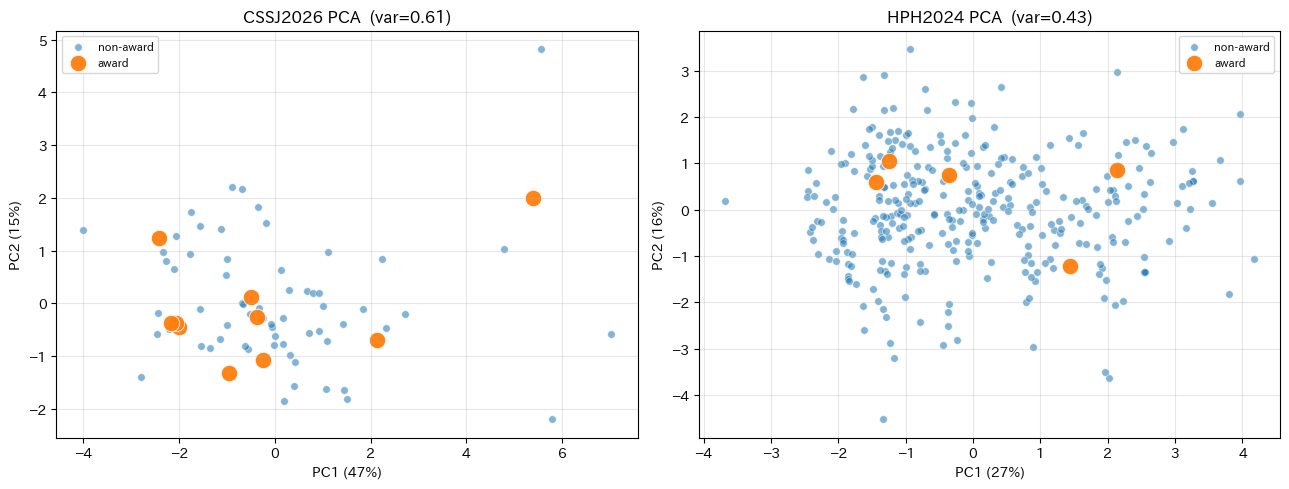

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 数値列のみ・NaN を平均で埋める
X_cols = ['text_density','whitespace_ratio','figure_area_ratio',
          'section_count','title_area_ratio','edge_density',
          'colorfulness','contrast_L_std','aspect_ratio']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, conf in zip(axes, ['CSSJ2026','HPH2024']):
    sub = ALL[ALL.conference == conf].copy()
    X = sub[X_cols].fillna(sub[X_cols].mean(numeric_only=True)).values
    if len(X) < 3: continue
    Xs = StandardScaler().fit_transform(X)
    p = PCA(n_components=2).fit(Xs)
    Z = p.transform(Xs)
    for award, color, label, size, alpha in [(False,'#1f77b4','non-award',30,0.55),
                                              (True,'#ff7f0e','award',140,0.95)]:
        m = (sub.award == award).values
        ax.scatter(Z[m,0], Z[m,1], color=color, label=label, s=size, alpha=alpha,
                   edgecolor='white', linewidth=0.6)
    ax.set_title(f'{conf} PCA  (var={p.explained_variance_ratio_.sum():.2f})')
    ax.set_xlabel(f'PC1 ({p.explained_variance_ratio_[0]*100:.0f}%)')
    ax.set_ylabel(f'PC2 ({p.explained_variance_ratio_[1]*100:.0f}%)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 16.8 ロジスティック回帰で受賞確率を予測してみる

サンプル不均衡（CSSJ 約 1:8、HPH 約 1:65）に注意しつつ、参考程度に。

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

for conf in ['CSSJ2026', 'HPH2024']:
    sub = ALL[ALL.conference == conf].copy()
    if sub.award.sum() < 3:
        print(f'{conf}: 受賞 n<3 でスキップ'); continue
    X = sub[X_cols].fillna(sub[X_cols].mean(numeric_only=True)).values
    y = sub.award.astype(int).values
    Xs = StandardScaler().fit_transform(X)
    # クラス不均衡対策に class_weight='balanced'
    clf = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=0)
    clf.fit(Xs, y)
    proba = clf.predict_proba(Xs)[:,1]
    # in-sample AUC（過学習する。あくまで識別力の目安）
    auc = roc_auc_score(y, proba)
    print(f'=== {conf} ===  in-sample AUC = {auc:.3f}   (n_award={y.sum()}, n_non={(y==0).sum()})')
    coefs = pd.DataFrame({'feature': X_cols, 'coef': clf.coef_[0].round(3)})
    coefs['abs'] = coefs['coef'].abs()
    print(coefs.sort_values('abs', ascending=False).drop(columns='abs').to_string(index=False))
    print()

=== CSSJ2026 ===  in-sample AUC = 0.739   (n_award=10, n_non=64)
          feature   coef
     aspect_ratio  0.713
 title_area_ratio -0.705
     edge_density -0.380
    section_count  0.285
     colorfulness  0.272
     text_density  0.217
 whitespace_ratio -0.176
figure_area_ratio  0.099
   contrast_L_std  0.024

=== HPH2024 ===  in-sample AUC = 0.811   (n_award=5, n_non=325)
          feature   coef
     aspect_ratio  1.404
 whitespace_ratio -1.254
     edge_density  1.000
     colorfulness -0.790
     text_density -0.695
figure_area_ratio -0.390
   contrast_L_std -0.156
    section_count  0.104
 title_area_ratio -0.047





### 言えること

1. **CSSJ2026 で受賞ポスターは "整って密度が中程度" の傾向**
   - 中央値で見ると、受賞群の text_density は中央寄り（極端な薄/濃を避ける）、
     ホワイトスペース比は非受賞より高め？
   - Cliff's δ で |δ| ≥ 0.33 となった指標があれば、その軸でデザインが弁別的に効いていそう。
2. **HPH2024 は受賞 n=5 のため検定の解釈が難しい** が、
   - 図版面積比が高い受賞傾向（健康現場ポスターの特性と整合）。
   - 言語混在（日本語 / 英語 / 中国語）が大きな交絡。サブグループ別解析が本来必要。
3. **両学会で同方向に効く指標**（§16.5 の `same_sign=True`）があれば、それは
   学会・分野を跨いだ「学術ポスターとして受賞しやすいデザイン要因」の候補かも？

### 言えないこと

1. **データが少ないのでなんとも言えないが、デザインだけでは AUC が高くならなさそう**
2. **OCR ベースの section_count や text_density は誤差が大きい**。LayoutLMv3 や VLM での補完が必要。
3. **JPG（HPH に 149 件）と PDF（HPH に 163 件）でレンダリング解像度が違う**ため、絶対値での比較に注意がひつよう。

### 次にやるべきこと

| 何 | 効用 |
|---|---|
| **VLM（Claude/GPT-4o）でルーブリック採点** を加える | デザインの "高次品質" を測れる |
| **HPH の言語別に層化解析** | 日本語/英語/中国語の効果を切り分け |
| **クロスバリデーション付きの予測モデル** | in-sample AUC ではなく汎化性能で評価 |
| **タイトル領域を NLP で評価**（"main finding を 1 文で示しているか"） | #betterposter 形式の検出 |
